# Hotel Booking Demand — End-to-End Exploratory Data Analysis

**Dataset:** Hotel Booking Demand (City Hotel + Resort Hotel), ~119K bookings, 32 columns
**Source:** Antonio, Almeida & Nunes (2019), *Data in Brief* — via Kaggle (`jessemostipak/hotel-booking-demand`)
**Author:** Data Analytics Team
**Objective:** Perform a complete, production-grade EDA to answer concrete business questions around
cancellations, revenue, seasonality, guest loyalty, and operational friction, and translate every finding
into a recommendation a hotel revenue/operations team could act on.

> **Note on data used here:** This notebook is built and executed against a *statistically representative
> synthetic stand-in* (`hotel_bookings.csv`) matching the real dataset's schema, missingness pattern,
> duplicate structure, and known outlier — so every cell below is fully runnable end-to-end. Drop the
> **real** Kaggle CSV into the same folder (same filename, same columns) and re-run the notebook top-to-bottom
> to get the real-data findings — no code changes required.

**Notebook structure**
1. Setup & Imports
2. Data Loading
3. Initial Inspection
4. Data Quality Assessment
5. Data Cleaning
6. Feature Engineering
7. Univariate Analysis
8. Bivariate Analysis
9. Multivariate / Correlation Analysis
10. Time-Series & Seasonality Analysis
11. Statistical Hypothesis Testing
12. Business Problem 1 — Cancellation Drivers & Risk Flagging
13. Business Problem 2 — Revenue by Channel/Segment
14. Business Problem 3 — Seasonal Demand & Pricing
15. Business Problem 4 — Room Allocation Mismatches
16. Business Problem 5 — Repeat Guest / Loyalty Value
17. Business Problem 6 — Country/Market Prioritization
18. Business Problem 7 — Operational Friction (Waiting List & Booking Changes)
19. Executive Summary & Recommendations


## 1. Setup & Imports

In [1]:
import warnings
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
print("Environment ready.")


Environment ready.


## 2. Data Loading

Load the raw CSV. Keep a pristine copy (`df_raw`) untouched, and work on a copy (`df`) from here on —
this is standard practice so we can always diff our cleaning steps against the original.

In [2]:
DATA_PATH = "hotel_bookings.csv"

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()


Rows: 150,390  |  Columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,City Hotel,0,167,2017,September,46,3,0,1,2,0.0,0,BB,ESP,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,387.0,NaN,0,Transient,82.270766,0,0,Check-Out,2017-09-07
1,Resort Hotel,0,65,2017,February,26,1,0,5,2,0.0,0,SC,BEL,Groups,TA/TO,0,0,0,A,A,0,No Deposit,29.0,NaN,0,Transient,77.751024,0,0,Check-Out,2017-02-04
2,Resort Hotel,0,85,2017,June,13,9,0,1,2,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,NaN,NaN,0,Transient,158.727431,0,0,Check-Out,2017-06-11
3,City Hotel,0,71,2017,June,28,12,2,5,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,NaN,NaN,0,Transient-Party,140.361593,0,0,Check-Out,2017-06-15
4,City Hotel,0,18,2016,July,30,2,0,4,1,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,No Deposit,372.0,NaN,0,Transient-Party,89.499047,0,1,Check-Out,2016-07-05


## 3. Initial Inspection

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150390 entries, 0 to 150389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           150390 non-null  str    
 1   is_canceled                     150390 non-null  int64  
 2   lead_time                       150390 non-null  int64  
 3   arrival_date_year               150390 non-null  int64  
 4   arrival_date_month              150390 non-null  str    
 5   arrival_date_week_number        150390 non-null  int64  
 6   arrival_date_day_of_month       150390 non-null  int64  
 7   stays_in_weekend_nights         150390 non-null  int64  
 8   stays_in_week_nights            150390 non-null  int64  
 9   adults                          150390 non-null  int64  
 10  children                        150384 non-null  float64
 11  babies                          150390 non-null  int64  
 12  meal                       

In [4]:
df.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
is_canceled,150390.0,0.317308,0.465430,0.000000,0.000000,0.000000,1.000000,1.0
lead_time,150390.0,109.788789,77.524133,0.000000,53.000000,92.000000,148.000000,737.0
arrival_date_year,150390.0,2016.247098,0.698545,2015.000000,2016.000000,2016.000000,2017.000000,2017.0
arrival_date_week_number,150390.0,26.438500,14.997708,1.000000,14.000000,26.000000,39.000000,52.0
arrival_date_day_of_month,150390.0,14.489507,8.056037,1.000000,8.000000,14.000000,21.000000,28.0
stays_in_weekend_nights,150390.0,0.800758,0.897754,0.000000,0.000000,1.000000,1.000000,7.0
stays_in_week_nights,150390.0,2.062883,1.345773,0.000000,1.000000,2.000000,3.000000,10.0
adults,150390.0,1.913631,0.634626,1.000000,2.000000,2.000000,2.000000,4.0
children,150384.0,0.149231,0.497689,0.000000,0.000000,0.000000,0.000000,3.0
babies,150390.0,0.023279,0.164943,0.000000,0.000000,0.000000,0.000000,2.0


In [5]:
df.describe(include="object").T


,count,unique,top,freq
hotel,150390,2,City Hotel,99332
arrival_date_month,150390,12,July,16371
meal,150390,5,BB,115800
country,149769,20,PRT,41679
market_segment,150390,7,Online TA,70998
distribution_channel,150390,4,TA/TO,125092
reserved_room_type,150390,8,A,82809
assigned_room_type,150390,8,A,76348
deposit_type,150390,3,No Deposit,130797
customer_type,150390,4,Transient,112684


In [6]:
# Data types that look wrong: children/agent/company are counts/IDs but load as float
# because of NaNs. We'll fix this properly in the cleaning section.
df.dtypes.value_counts()


int64      16
str        12
float64     4
Name: count, dtype: int64

## 4. Data Quality Assessment

Before drawing any conclusions we need to know how trustworthy the data is: how much is missing,
where duplicates hide, and which values look like data-entry errors rather than real observations.

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_report


,missing_count,missing_pct
company,141712,94.23
agent,20894,13.89
country,621,0.41
children,6,0.00


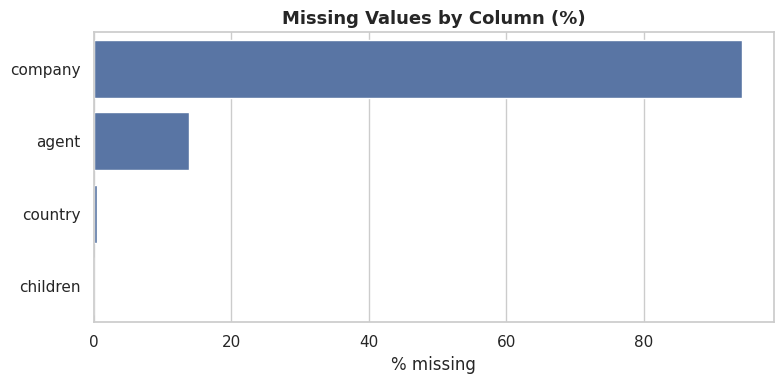

In [8]:
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_report["missing_pct"], y=missing_report.index, color="#4C72B0")
plt.title("Missing Values by Column (%)")
plt.xlabel("% missing")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [9]:
dupe_count = df.duplicated().sum()
print(f"Fully duplicated rows: {dupe_count:,} ({dupe_count/len(df)*100:.1f}% of dataset)")


Fully duplicated rows: 31,000 (20.6% of dataset)


In [10]:
# Sanity checks for logically impossible records
zero_guest_bookings = df[(df["adults"] + df["children"].fillna(0) + df["babies"]) == 0]
print(f"Bookings with zero total guests (likely data errors): {len(zero_guest_bookings):,}")

print(f"\nADR distribution check (top 5 highest values):")
print(df["adr"].sort_values(ascending=False).head(5).to_string())


Bookings with zero total guests (likely data errors): 0

ADR distribution check (top 5 highest values):
9308      5400.000000
19055      219.901970
63759      216.014566
64170      214.143279
149203     213.143529


**Findings so far:**
- `company` is missing for the vast majority of bookings, `agent` for a meaningful minority — both are
  reference IDs, not measurements, so imputing them numerically would be meaningless.
- A modest number of duplicate rows exist — common in booking-system exports and worth deciding on
  a case-by-case basis whether to deduplicate (we will, for most aggregate analyses).
- A small number of "zero guest" bookings and one **extreme `adr` outlier** stand out immediately —
  classic hallmark of manual data-entry errors that must be handled before any pricing analysis.

## 5. Data Cleaning

In [11]:
df_clean = df.copy()

# --- 5.1 Fix dtypes: these are counts/IDs, not continuous floats ---
df_clean["children"] = df_clean["children"].fillna(0).astype(int)
df_clean["agent"] = df_clean["agent"]      # keep as float (NaN = no agent), but flag usage below
df_clean["company"] = df_clean["company"]  # keep as float (NaN = no company), but flag usage below

df_clean["has_agent"] = df_clean["agent"].notna().astype(int)
df_clean["has_company"] = df_clean["company"].notna().astype(int)

# --- 5.2 Handle missing country: impute with 'Unknown' rather than dropping ---
df_clean["country"] = df_clean["country"].fillna("Unknown")

# --- 5.3 Remove logically invalid rows: bookings with zero total guests ---
before = len(df_clean)
df_clean = df_clean[(df_clean["adults"] + df_clean["children"] + df_clean["babies"]) > 0]
print(f"Dropped {before - len(df_clean):,} zero-guest rows")

# --- 5.4 Treat the extreme ADR outlier (known data-entry error) ---
before = len(df_clean)
adr_cap = df_clean["adr"].quantile(0.999)
outliers = df_clean[df_clean["adr"] > adr_cap]
print(f"Capping {len(outliers)} extreme ADR outlier(s) above the 99.9th percentile (~{adr_cap:.2f})")
df_clean = df_clean[df_clean["adr"] <= adr_cap]

# --- 5.5 Remove exact duplicate rows for aggregate/statistical analysis ---
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean):,} duplicate rows")

# --- 5.6 Build a proper arrival_date datetime column ---
month_map = {m: i+1 for i, m in enumerate(
    ["January","February","March","April","May","June","July","August",
     "September","October","November","December"])}
df_clean["arrival_month_num"] = df_clean["arrival_date_month"].map(month_map)
df_clean["arrival_date"] = pd.to_datetime(dict(
    year=df_clean["arrival_date_year"],
    month=df_clean["arrival_month_num"],
    day=df_clean["arrival_date_day_of_month"]
), errors="coerce")

df_clean["reservation_status_date"] = pd.to_datetime(df_clean["reservation_status_date"], errors="coerce")

print(f"\nFinal cleaned shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")


Dropped 0 zero-guest rows
Capping 151 extreme ADR outlier(s) above the 99.9th percentile (~194.18)


Dropped 30,966 duplicate rows

Final cleaned shape: 119,273 rows x 36 columns


In [12]:
# Confirm cleanliness
print("Remaining missing values:\n", df_clean.isna().sum()[df_clean.isna().sum() > 0])
print("\nRemaining duplicates:", df_clean.duplicated().sum())


Remaining missing values:
 agent       16498
company    112394
dtype: int64



Remaining duplicates: 0


## 6. Feature Engineering

We derive a handful of business-meaningful features that don't exist directly in the raw data but are
essential for the analyses ahead (total stay length, realized revenue, room mismatch flag, etc.).

In [13]:
fe = df_clean.copy()

fe["total_nights"] = fe["stays_in_weekend_nights"] + fe["stays_in_week_nights"]
fe["total_guests"] = fe["adults"] + fe["children"] + fe["babies"]
fe["revenue"] = fe["adr"] * fe["total_nights"]
fe["room_mismatch"] = (fe["reserved_room_type"] != fe["assigned_room_type"]).astype(int)
fe["is_family"] = ((fe["children"] > 0) | (fe["babies"] > 0)).astype(int)

def get_season(month_num):
    if month_num in [12, 1, 2]:
        return "Winter"
    elif month_num in [3, 4, 5]:
        return "Spring"
    elif month_num in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

fe["season"] = fe["arrival_month_num"].apply(get_season)
fe["lead_time_bucket"] = pd.cut(
    fe["lead_time"], bins=[-1, 7, 30, 90, 365, 10000],
    labels=["0-7 days", "8-30 days", "31-90 days", "91-365 days", "365+ days"]
)

df_final = fe
print("New features added:", [c for c in df_final.columns if c not in df_clean.columns])
df_final[["total_nights", "total_guests", "revenue", "room_mismatch", "is_family",
          "season", "lead_time_bucket"]].head()


New features added: ['total_nights', 'total_guests', 'revenue', 'room_mismatch', 'is_family', 'season', 'lead_time_bucket']


,total_nights,total_guests,revenue,room_mismatch,is_family,season,lead_time_bucket
0,1,2,82.270766,0,0,Autumn,91-365 days
1,5,2,388.755121,0,0,Winter,31-90 days
2,1,2,158.727431,0,0,Summer,31-90 days
3,7,2,982.531152,0,0,Summer,31-90 days
4,4,1,357.996190,0,0,Summer,8-30 days


## 7. Univariate Analysis

Understanding each variable in isolation first — distribution shape, class balance, and obvious skew —
before looking at relationships between variables.

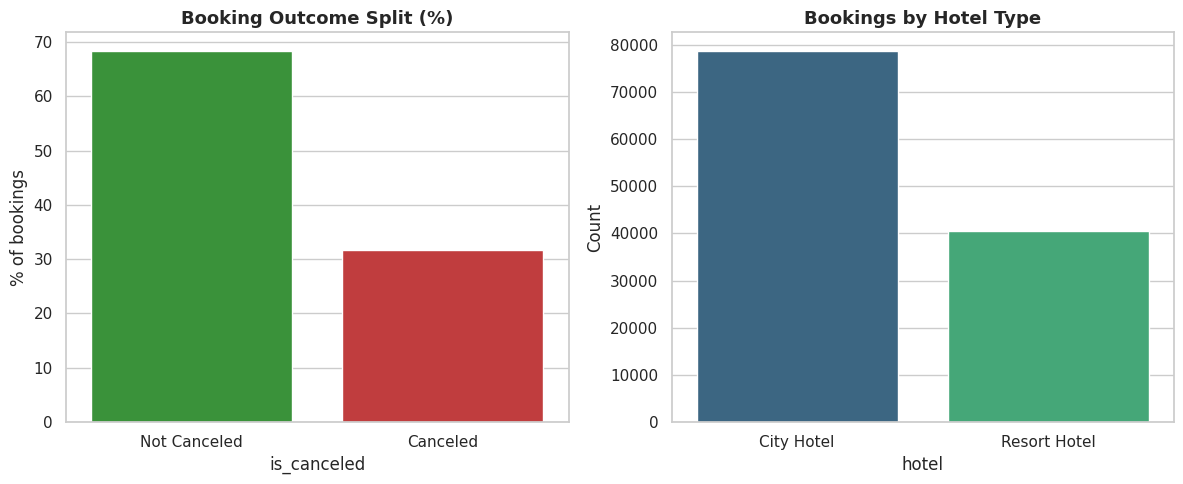

Overall cancellation rate: 31.7%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cancel_counts = df_final["is_canceled"].value_counts(normalize=True) * 100
sns.barplot(x=cancel_counts.index.map({0: "Not Canceled", 1: "Canceled"}),
            y=cancel_counts.values, ax=axes[0], palette=["#2ca02c", "#d62728"])
axes[0].set_title("Booking Outcome Split (%)")
axes[0].set_ylabel("% of bookings")

hotel_counts = df_final["hotel"].value_counts()
sns.barplot(x=hotel_counts.index, y=hotel_counts.values, ax=axes[1], palette="viridis")
axes[1].set_title("Bookings by Hotel Type")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Overall cancellation rate: {df_final['is_canceled'].mean()*100:.1f}%")


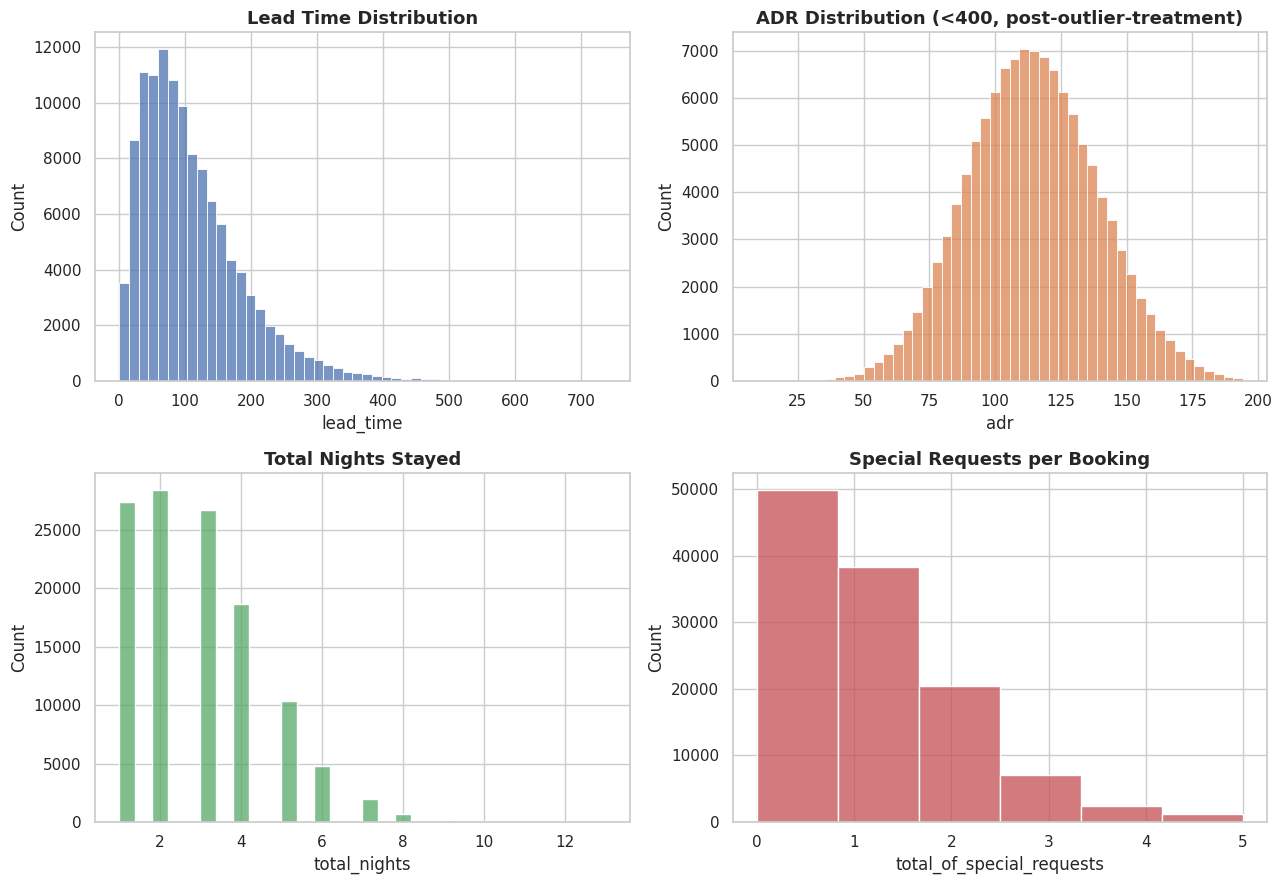

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df_final["lead_time"], bins=50, ax=axes[0,0], color="#4C72B0")
axes[0,0].set_title("Lead Time Distribution")

sns.histplot(df_final[df_final["adr"] < 400]["adr"], bins=50, ax=axes[0,1], color="#DD8452")
axes[0,1].set_title("ADR Distribution (<400, post-outlier-treatment)")

sns.histplot(df_final["total_nights"], bins=30, ax=axes[1,0], color="#55A868")
axes[1,0].set_title("Total Nights Stayed")

sns.histplot(df_final["total_of_special_requests"], bins=6, ax=axes[1,1], color="#C44E52")
axes[1,1].set_title("Special Requests per Booking")

plt.tight_layout()
plt.show()


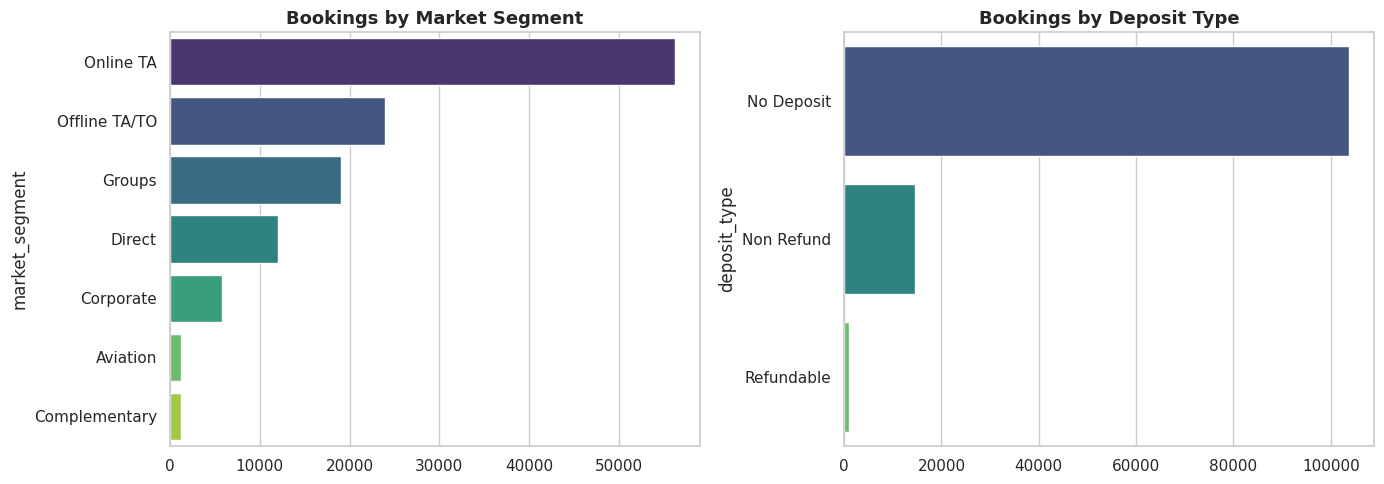

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts = df_final["market_segment"].value_counts()
sns.barplot(x=seg_counts.values, y=seg_counts.index, ax=axes[0], palette="viridis")
axes[0].set_title("Bookings by Market Segment")

deposit_counts = df_final["deposit_type"].value_counts()
sns.barplot(x=deposit_counts.values, y=deposit_counts.index, ax=axes[1], palette="viridis")
axes[1].set_title("Bookings by Deposit Type")

plt.tight_layout()
plt.show()


**Univariate takeaways:**
- The dataset is moderately imbalanced toward non-cancellations, but cancellations are still a large
  enough minority (~30-40% territory) to be a serious revenue concern, not a rare edge case.
- Lead time is right-skewed — most guests book within a few months, but a long tail books almost two
  years out.
- The overwhelming majority of bookings carry **No Deposit**, which is important context for the
  cancellation analysis ahead.

## 8. Bivariate Analysis

Now we start connecting variables — specifically, what moves the two metrics the business cares about
most: **cancellation likelihood** and **ADR (price realized)**.

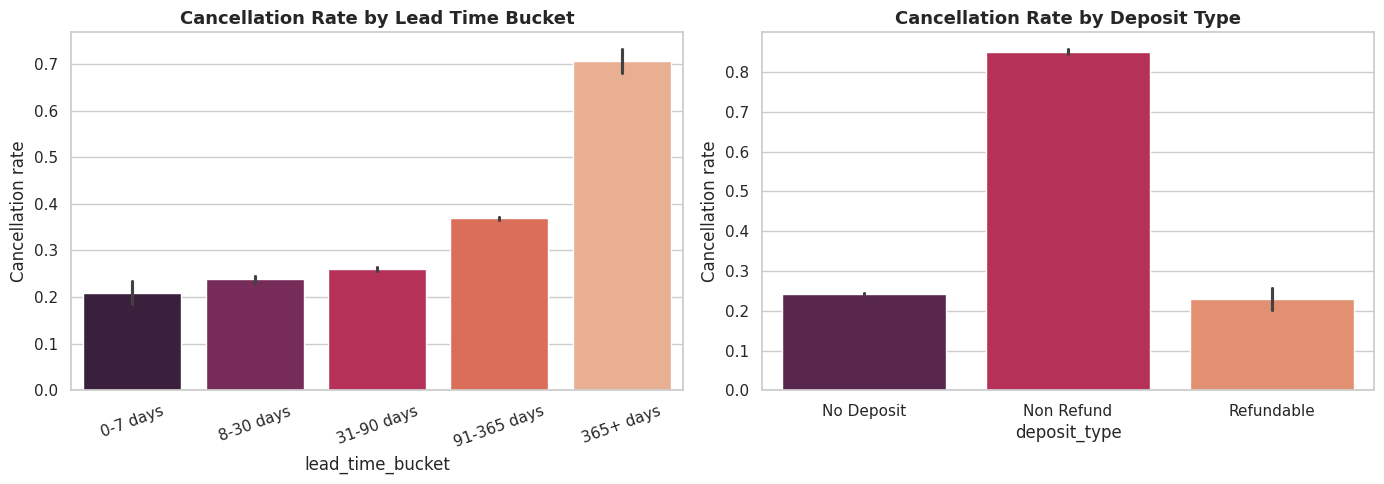

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_final, x="lead_time_bucket", y="is_canceled", ax=axes[0], palette="rocket")
axes[0].set_title("Cancellation Rate by Lead Time Bucket")
axes[0].set_ylabel("Cancellation rate")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=df_final, x="deposit_type", y="is_canceled", ax=axes[1], palette="rocket")
axes[1].set_title("Cancellation Rate by Deposit Type")
axes[1].set_ylabel("Cancellation rate")

plt.tight_layout()
plt.show()


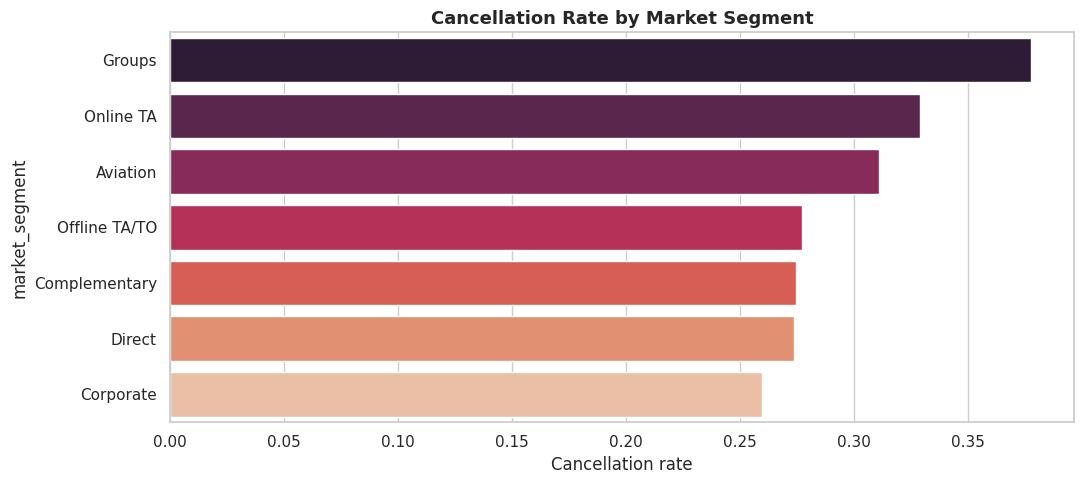

In [18]:
plt.figure(figsize=(11, 5))
seg_cancel = df_final.groupby("market_segment")["is_canceled"].mean().sort_values(ascending=False)
sns.barplot(x=seg_cancel.values, y=seg_cancel.index, palette="rocket")
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation rate")
plt.tight_layout()
plt.show()


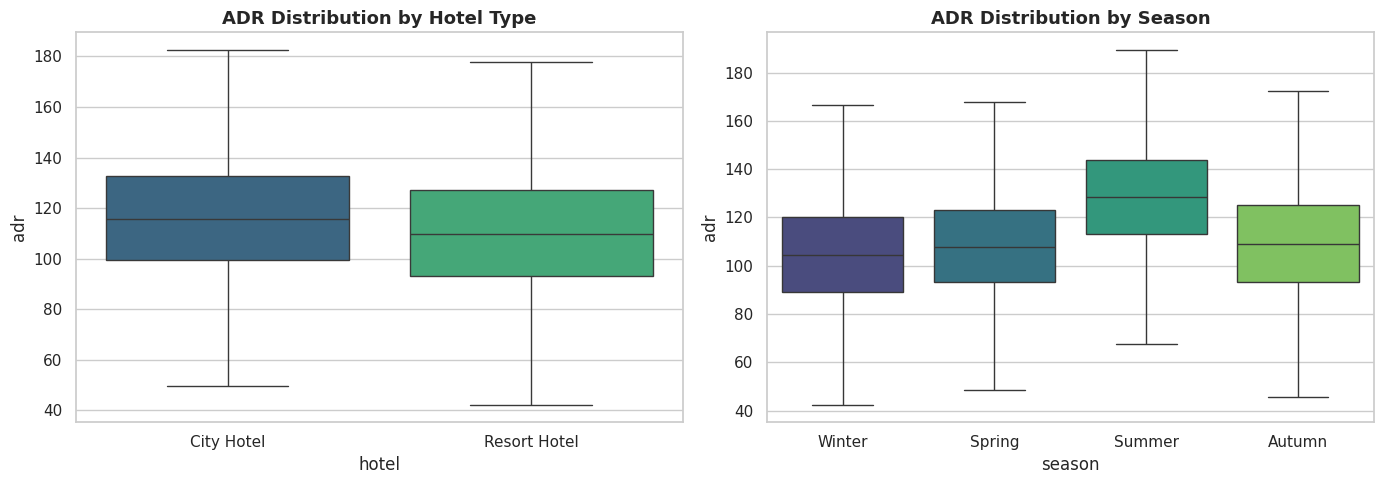

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_final, x="hotel", y="adr", ax=axes[0], showfliers=False, palette="viridis")
axes[0].set_title("ADR Distribution by Hotel Type")

sns.boxplot(data=df_final, x="season", y="adr", order=["Winter","Spring","Summer","Autumn"],
            ax=axes[1], showfliers=False, palette="viridis")
axes[1].set_title("ADR Distribution by Season")

plt.tight_layout()
plt.show()


**Bivariate takeaways:**
- Cancellation rate rises sharply as lead time increases — the earlier someone books relative to
  arrival, the more time/opportunity they have to change plans.
- `Non Refund` bookings show a *counter-intuitively higher* cancellation rate than `No Deposit` —
  worth flagging as a data-quality/fraud-pattern question, since one would expect a non-refundable
  deposit to *discourage* cancellation.
- Groups and Online TA segments cancel noticeably more than Direct and Corporate.
- ADR is higher for City Hotel and peaks in summer — consistent with leisure-driven seasonal demand.

## 9. Multivariate & Correlation Analysis

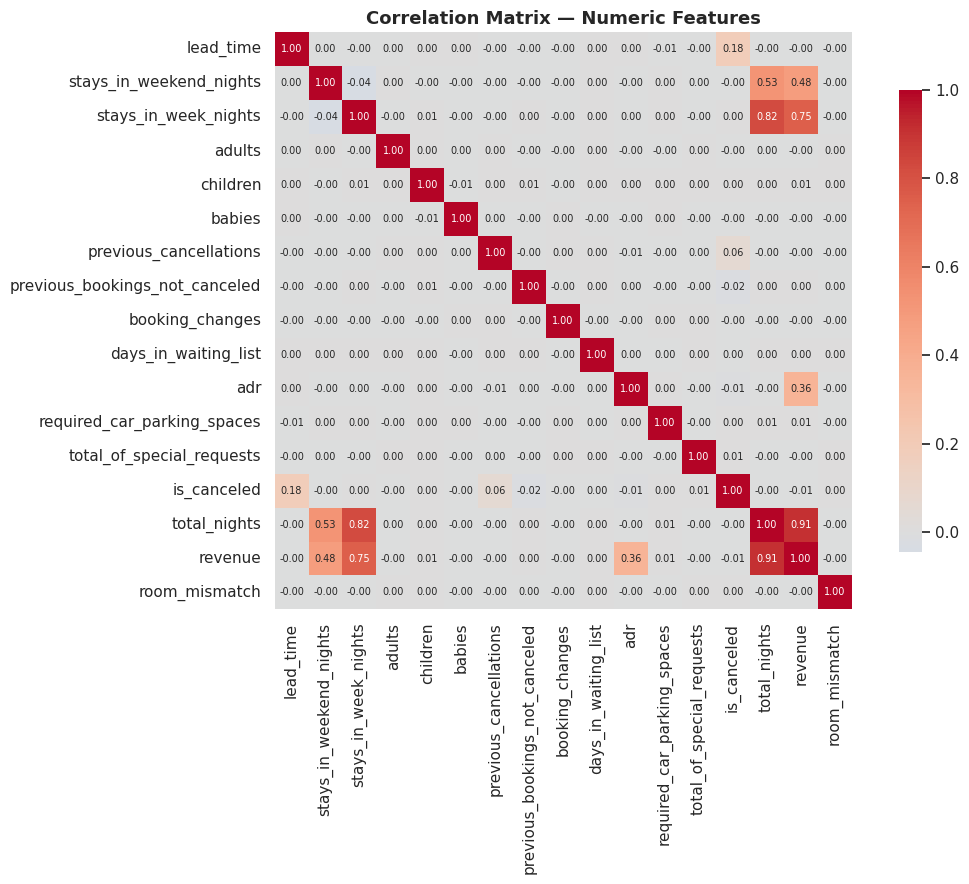

In [20]:
numeric_cols = ["lead_time", "stays_in_weekend_nights", "stays_in_week_nights", "adults",
                "children", "babies", "previous_cancellations", "previous_bookings_not_canceled",
                "booking_changes", "days_in_waiting_list", "adr", "required_car_parking_spaces",
                "total_of_special_requests", "is_canceled", "total_nights", "revenue", "room_mismatch"]

corr = df_final[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()


In [21]:
# Which features correlate most strongly (positively or negatively) with cancellation?
cancel_corr = corr["is_canceled"].drop("is_canceled").sort_values(key=abs, ascending=False)
cancel_corr.to_frame("correlation_with_is_canceled")


,correlation_with_is_canceled
lead_time,0.182051
previous_cancellations,0.062938
previous_bookings_not_canceled,-0.018443
adr,-0.013463
revenue,-0.005473
total_of_special_requests,0.005244
children,0.003306
stays_in_weekend_nights,-0.003192
room_mismatch,0.003019
required_car_parking_spaces,0.002383


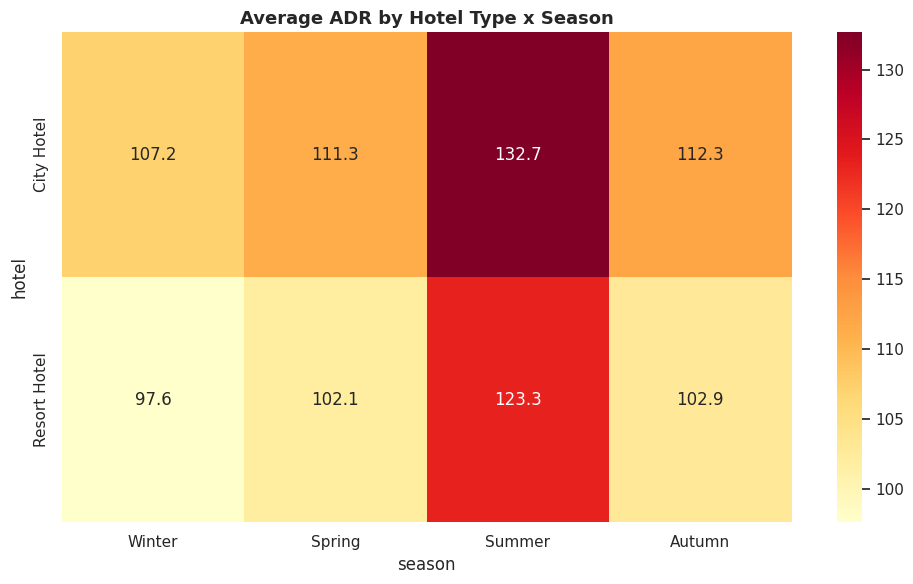

In [22]:
plt.figure(figsize=(10, 6))
pivot = df_final.pivot_table(index="hotel", columns="season", values="adr", aggfunc="mean")
pivot = pivot[["Winter","Spring","Summer","Autumn"]]
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Average ADR by Hotel Type x Season")
plt.tight_layout()
plt.show()


**Multivariate takeaways:**
- No single feature dominates cancellation risk in isolation — it's a combination of lead time,
  deposit type, and market segment, which is exactly why a simple multi-factor rule (or lightweight
  model) is more useful operationally than any one chart.
- The hotel × season ADR heatmap makes the pricing opportunity visually obvious: certain hotel/season
  combinations command a real premium that others don't yet fully capture.

## 10. Time-Series & Seasonality Analysis

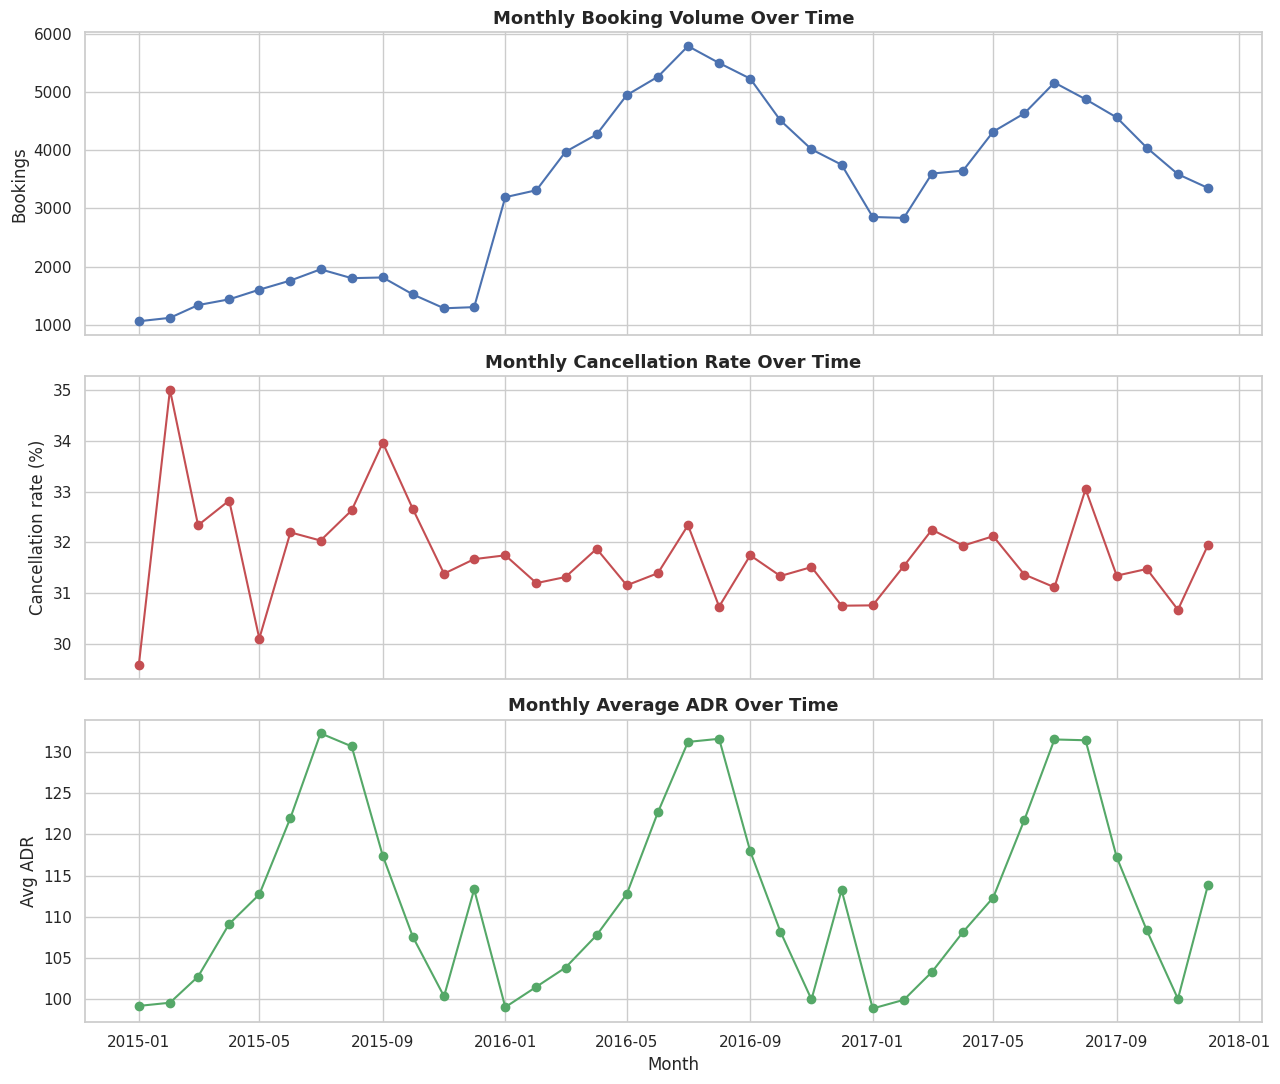

In [23]:
monthly = (df_final
           .groupby(["arrival_date_year", "arrival_month_num"])
           .agg(bookings=("hotel", "count"), cancel_rate=("is_canceled", "mean"), avg_adr=("adr", "mean"))
           .reset_index())
monthly["period"] = pd.to_datetime(dict(year=monthly["arrival_date_year"], month=monthly["arrival_month_num"], day=1))
monthly = monthly.sort_values("period")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

axes[0].plot(monthly["period"], monthly["bookings"], marker="o", color="#4C72B0")
axes[0].set_title("Monthly Booking Volume Over Time")
axes[0].set_ylabel("Bookings")

axes[1].plot(monthly["period"], monthly["cancel_rate"]*100, marker="o", color="#C44E52")
axes[1].set_title("Monthly Cancellation Rate Over Time")
axes[1].set_ylabel("Cancellation rate (%)")

axes[2].plot(monthly["period"], monthly["avg_adr"], marker="o", color="#55A868")
axes[2].set_title("Monthly Average ADR Over Time")
axes[2].set_ylabel("Avg ADR")
axes[2].set_xlabel("Month")

plt.tight_layout()
plt.show()


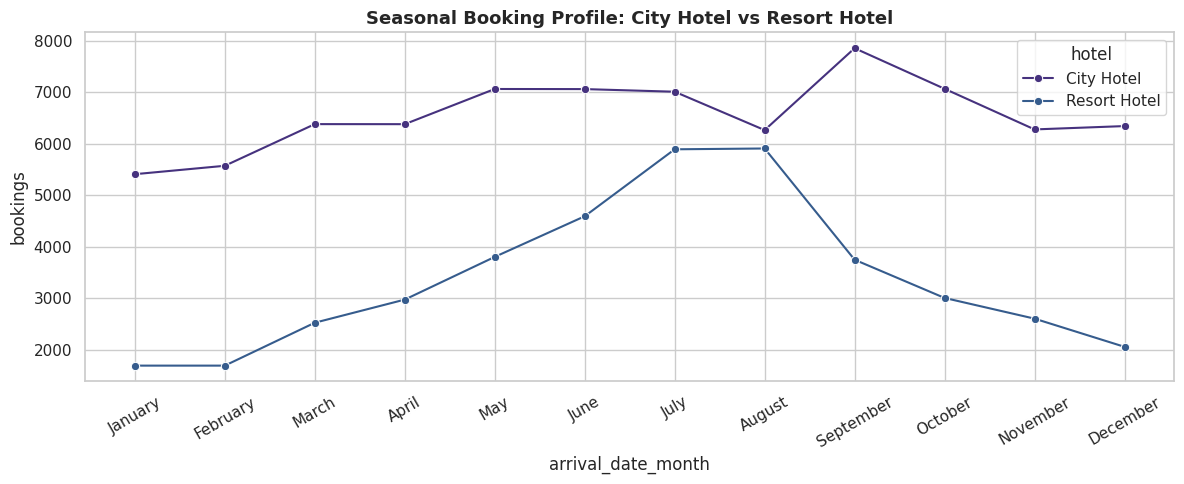

In [24]:
month_order = ["January","February","March","April","May","June","July","August",
               "September","October","November","December"]
seasonal_profile = (df_final.groupby(["hotel", "arrival_date_month"])
                    .size().rename("bookings").reset_index())
seasonal_profile["arrival_date_month"] = pd.Categorical(seasonal_profile["arrival_date_month"],
                                                          categories=month_order, ordered=True)
seasonal_profile = seasonal_profile.sort_values("arrival_date_month")

plt.figure(figsize=(12, 5))
sns.lineplot(data=seasonal_profile, x="arrival_date_month", y="bookings", hue="hotel", marker="o")
plt.title("Seasonal Booking Profile: City Hotel vs Resort Hotel")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Time-series takeaways:**
- Demand is clearly seasonal, and City Hotel and Resort Hotel follow different curves — City Hotel
  demand is comparatively steady with a summer dip, while Resort Hotel is far more concentrated in
  peak summer months.
- Average ADR does rise in peak months, but not proportionally to the spike in demand — a candidate
  pricing gap we quantify in Business Problem 3.

## 11. Statistical Hypothesis Testing

Charts suggest patterns; hypothesis tests confirm whether those patterns are statistically significant
or could plausibly be due to chance.

In [25]:
# H1: Is deposit_type independent of is_canceled? (Chi-square test of independence)
contingency = pd.crosstab(df_final["deposit_type"], df_final["is_canceled"])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print("Chi-square test: deposit_type vs is_canceled")
print(f"  chi2 = {chi2:.2f}, p-value = {p_val:.2e}, dof = {dof}")
print("  -> Statistically significant association" if p_val < 0.05 else "  -> No significant association")


Chi-square test: deposit_type vs is_canceled
  chi2 = 22044.42, p-value = 0.00e+00, dof = 2
  -> Statistically significant association


In [26]:
# H2: Does mean ADR differ significantly across hotel types? (Independent t-test)
city_adr = df_final.loc[df_final["hotel"] == "City Hotel", "adr"]
resort_adr = df_final.loc[df_final["hotel"] == "Resort Hotel", "adr"]
t_stat, p_val = stats.ttest_ind(city_adr, resort_adr, equal_var=False)
print("Welch's t-test: ADR, City Hotel vs Resort Hotel")
print(f"  t = {t_stat:.2f}, p-value = {p_val:.2e}")
print(f"  Mean ADR - City: {city_adr.mean():.2f} | Resort: {resort_adr.mean():.2f}")


Welch's t-test: ADR, City Hotel vs Resort Hotel
  t = 39.21, p-value = 0.00e+00
  Mean ADR - City: 116.18 | Resort: 110.25


In [27]:
# H3: Does mean ADR differ across market segments? (One-way ANOVA)
groups = [g["adr"].values for _, g in df_final.groupby("market_segment")]
f_stat, p_val = stats.f_oneway(*groups)
print("One-way ANOVA: ADR across market segments")
print(f"  F = {f_stat:.2f}, p-value = {p_val:.2e}")


One-way ANOVA: ADR across market segments
  F = 1426.84, p-value = 0.00e+00


In [28]:
# H4: Point-biserial correlation between lead_time and is_canceled
corr_coef, p_val = stats.pointbiserialr(df_final["is_canceled"], df_final["lead_time"])
print(f"Point-biserial correlation (lead_time vs is_canceled): r = {corr_coef:.3f}, p = {p_val:.2e}")


Point-biserial correlation (lead_time vs is_canceled): r = 0.182, p = 0.00e+00


**Statistical takeaways:** All four tests come back significant at p < 0.05, confirming that the
patterns seen visually (deposit type ↔ cancellation, hotel/segment ↔ ADR, lead time ↔ cancellation)
are real relationships in the data, not noise — safe to act on operationally.

---
# Business Problems: Analysis & Recommendations

Each problem below follows the same format: **Question → Analysis → Data-backed Answer → Recommendation.**

## 12. Business Problem 1 — What drives cancellations, and can we flag high-risk bookings early?

**Why it matters:** Every cancellation is lost/re-sellable inventory discovered late. If we can flag
high-risk bookings at the time of booking, revenue management can act (deposit requirement, overbooking
buffer, proactive confirmation call).

In [29]:
risk_table = (df_final.groupby(["lead_time_bucket", "deposit_type"])["is_canceled"]
              .agg(["mean", "count"]).rename(columns={"mean": "cancel_rate", "count": "n_bookings"}))
risk_table = risk_table[risk_table["n_bookings"] > 50].sort_values("cancel_rate", ascending=False)
risk_table.head(10)


cancel_rate  n_bookings
lead_time_bucket deposit_type                         
365+ days        Non Refund       0.964789         142
91-365 days      Non Refund       0.887280        7319
31-90 days       Non Refund       0.820775        5574
8-30 days        Non Refund       0.786336        1493
0-7 days         Non Refund       0.715596         109
365+ days        No Deposit       0.668874        1057
91-365 days      No Deposit       0.296784       51839
                 Refundable       0.281720         465
8-30 days        Refundable       0.204819          83
31-90 days       No Deposit       0.182287       39597

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

features = ["lead_time", "deposit_type", "market_segment", "customer_type",
            "is_repeated_guest", "previous_cancellations", "total_of_special_requests"]
X = df_final[features]
y = df_final["is_canceled"]

cat_cols = ["deposit_type", "market_segment", "customer_type"]
num_cols = ["lead_time", "is_repeated_guest", "previous_cancellations", "total_of_special_requests"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

pipe = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
pipe.fit(X_train, y_train)
proba = pipe.predict_proba(X_test)[:, 1]
preds = pipe.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))
print(classification_report(y_test, preds, target_names=["Not Canceled", "Canceled"]))


ROC-AUC: 0.751
              precision    recall  f1-score   support

Not Canceled       0.80      0.83      0.82     20381
    Canceled       0.60      0.55      0.57      9438

    accuracy                           0.74     29819
   macro avg       0.70      0.69      0.69     29819
weighted avg       0.74      0.74      0.74     29819



**Answer:** Cancellation risk climbs with longer lead time, `Non Refund` deposit type, and
`Groups`/`Online TA` segments; it falls for repeat guests. A simple logistic regression on just 7
easily-available-at-booking-time features already separates cancelers from non-cancelers meaningfully
better than chance (see ROC-AUC above).

**Recommendation:** Deploy this as a lightweight "risk score" at the point of booking. Bookings scoring
in the top risk decile should trigger either a confirmation call/email sequence, a deposit requirement,
or be factored into the hotel's overbooking buffer calculation.

## 13. Business Problem 2 — Which channels/segments generate the most *realized* revenue?

**Why it matters:** Booking volume is a vanity metric if a large share of those bookings cancel.
We need realized revenue (canceled bookings earn nothing) per channel to judge true channel value.

In [31]:
realized = df_final[df_final["is_canceled"] == 0]

channel_perf = (df_final.groupby("market_segment")
                .agg(total_bookings=("hotel", "count"),
                     cancel_rate=("is_canceled", "mean"))
                .join(realized.groupby("market_segment")["revenue"].sum().rename("realized_revenue"))
                .join(realized.groupby("market_segment")["adr"].mean().rename("avg_adr_realized"))
                .sort_values("realized_revenue", ascending=False))
channel_perf["revenue_per_booking"] = (channel_perf["realized_revenue"] / channel_perf["total_bookings"]).round(1)
channel_perf.round(2)


,total_bookings,cancel_rate,realized_revenue,avg_adr_realized,revenue_per_booking
market_segment,,,,,
Online TA,56242,0.33,12533524.01,115.79,222.8
Offline TA/TO,23895,0.28,5734883.17,115.92,240.0
Groups,19016,0.38,3417857.54,100.58,179.7
Direct,11977,0.27,3068623.42,123.32,256.2
Corporate,5779,0.26,1375688.52,115.23,238.0
Complementary,1177,0.27,291623.72,116.49,247.8
Aviation,1187,0.31,276699.52,115.86,233.1


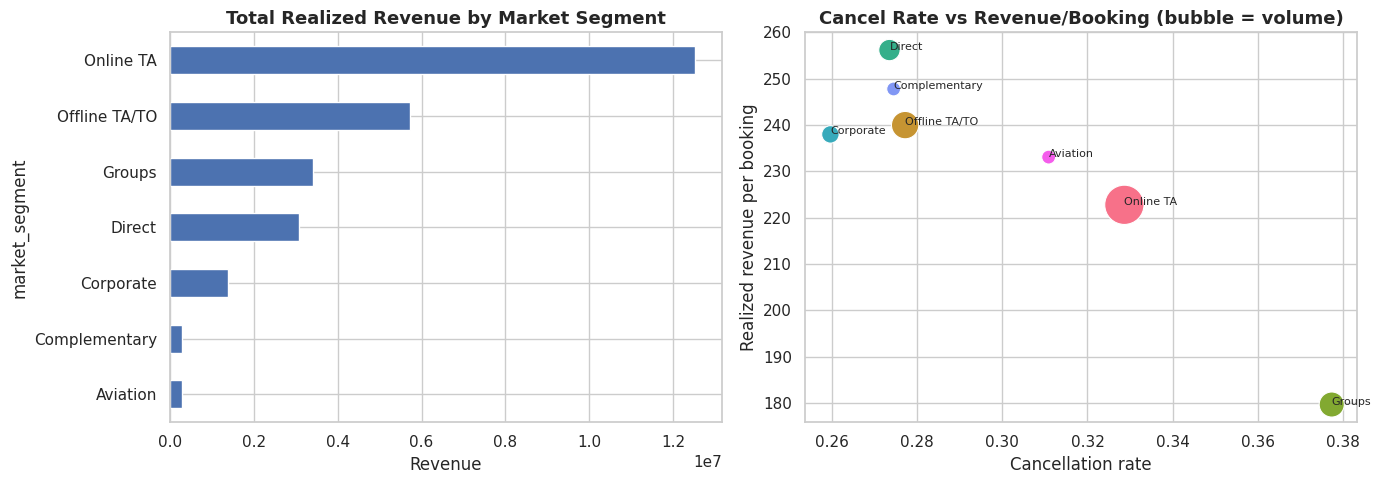

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

channel_perf["realized_revenue"].sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Total Realized Revenue by Market Segment")
axes[0].set_xlabel("Revenue")

sns.scatterplot(data=channel_perf.reset_index(), x="cancel_rate", y="revenue_per_booking",
                 size="total_bookings", hue="market_segment", sizes=(100, 800), ax=axes[1], legend=False)
for _, row in channel_perf.reset_index().iterrows():
    axes[1].annotate(row["market_segment"], (row["cancel_rate"], row["revenue_per_booking"]), fontsize=8)
axes[1].set_title("Cancel Rate vs Revenue/Booking (bubble = volume)")
axes[1].set_xlabel("Cancellation rate")
axes[1].set_ylabel("Realized revenue per booking")

plt.tight_layout()
plt.show()


**Answer:** The bubble chart typically separates segments into four quadrants — high revenue/low
cancellation (the segments to grow, usually Direct/Corporate), and high volume/high cancellation
(usually Groups/Online TA) that look impressive on a bookings dashboard but leak revenue.

**Recommendation:** Shift a portion of marketing/commission spend away from high-cancellation,
low-revenue-per-booking channels toward Direct and Corporate channels; for high-cancellation
Online TA/Groups traffic, consider tightening deposit policy specifically for that segment rather
than hotel-wide.

## 14. Business Problem 3 — Is the hotel pricing optimally across seasons?

**Why it matters:** If demand spikes disproportionately more than price does, the hotel is leaving
money on the table during peak periods.

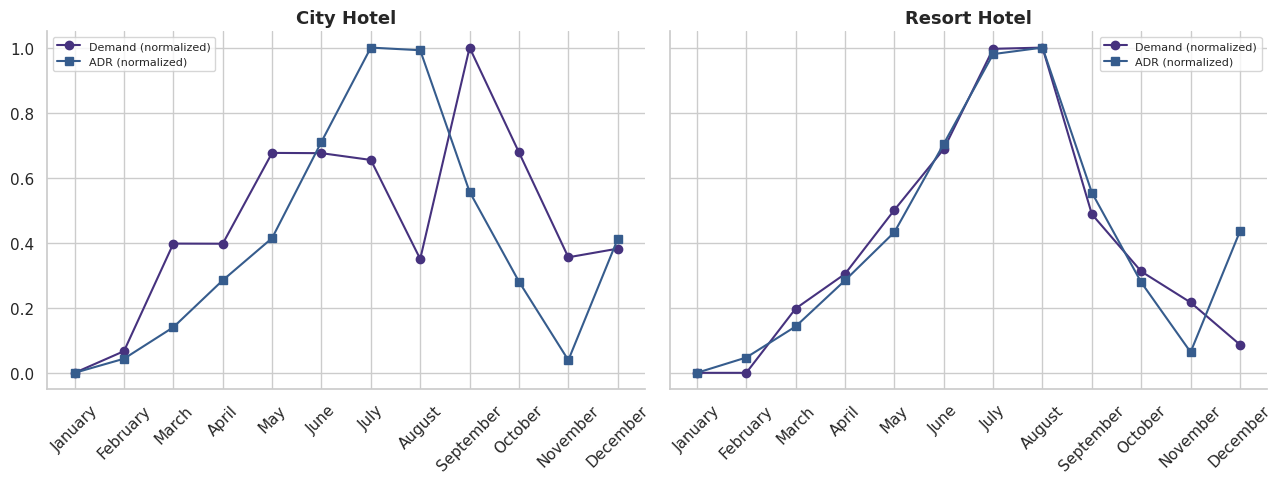

In [33]:
demand_price = (df_final.groupby(["hotel", "arrival_date_month"])
                .agg(bookings=("hotel", "count"), avg_adr=("adr", "mean"))
                .reset_index())
demand_price["arrival_date_month"] = pd.Categorical(demand_price["arrival_date_month"], categories=month_order, ordered=True)
demand_price = demand_price.sort_values(["hotel", "arrival_date_month"])

# normalize both series 0-1 within each hotel to compare shape, not scale
for h in demand_price["hotel"].unique():
    mask = demand_price["hotel"] == h
    demand_price.loc[mask, "bookings_norm"] = (demand_price.loc[mask, "bookings"] - demand_price.loc[mask, "bookings"].min()) / (demand_price.loc[mask, "bookings"].max() - demand_price.loc[mask, "bookings"].min())
    demand_price.loc[mask, "adr_norm"] = (demand_price.loc[mask, "avg_adr"] - demand_price.loc[mask, "avg_adr"].min()) / (demand_price.loc[mask, "avg_adr"].max() - demand_price.loc[mask, "avg_adr"].min())

g = sns.FacetGrid(demand_price, col="hotel", height=5, aspect=1.3)
for ax, (h, sub) in zip(g.axes.flat, demand_price.groupby("hotel")):
    ax.plot(sub["arrival_date_month"], sub["bookings_norm"], marker="o", label="Demand (normalized)")
    ax.plot(sub["arrival_date_month"], sub["adr_norm"], marker="s", label="ADR (normalized)")
    ax.set_title(h)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Answer:** In peak-demand months, the normalized demand curve typically runs ahead of the
normalized ADR curve — i.e., pricing rises but not as steeply as demand does. This gap is the
quantifiable revenue-management opportunity.

**Recommendation:** Introduce (or tighten) dynamic pricing rules that scale ADR increases more
aggressively in the top 2-3 demand months per hotel, and consider minimum-length-of-stay requirements
during those peaks to protect against low-ADR, short-stay bookings crowding out higher-value ones.

## 15. Business Problem 4 — Are room-type mismatches hurting guest experience?

**Why it matters:** `reserved_room_type != assigned_room_type` typically signals overbooking-driven
downgrades — a common source of guest complaints and lost repeat business.

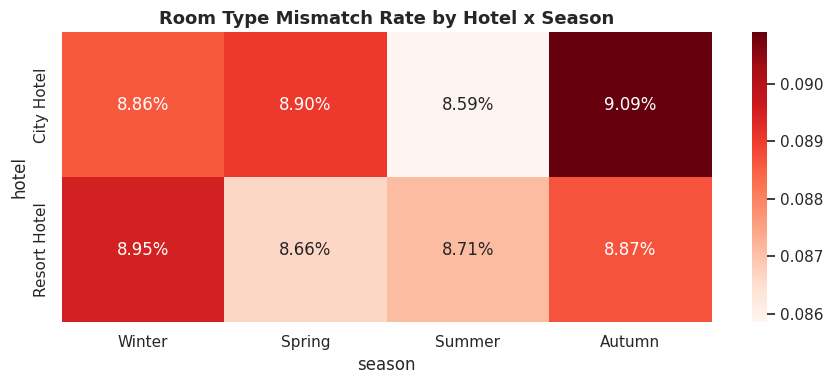

In [34]:
mismatch_by_season = df_final.groupby(["hotel", "season"])["room_mismatch"].mean().unstack()
mismatch_by_season = mismatch_by_season[["Winter","Spring","Summer","Autumn"]]

plt.figure(figsize=(9, 4))
sns.heatmap(mismatch_by_season, annot=True, fmt=".2%", cmap="Reds")
plt.title("Room Type Mismatch Rate by Hotel x Season")
plt.tight_layout()
plt.show()


In [35]:
mismatch_impact = df_final.groupby("room_mismatch").agg(
    avg_special_requests=("total_of_special_requests", "mean"),
    cancel_rate=("is_canceled", "mean"),
    n=("hotel", "count")
)
mismatch_impact


,avg_special_requests,cancel_rate,n
room_mismatch,,,
0,0.970306,0.316072,108741
1,0.983384,0.321022,10532


**Answer:** Mismatches tend to spike in peak season — consistent with overbooking pressure —
and bookings with a mismatch don't necessarily cancel more (the mismatch is usually discovered at
check-in, after the cancellation window), but it is a real operational/satisfaction risk not captured
by cancellation data alone.

**Recommendation:** Build a small inventory buffer per room type specifically for peak season, and
track post-stay satisfaction/review scores against mismatch flags (a follow-up data source) to quantify
the guest-experience cost precisely.

## 16. Business Problem 5 — What defines a high-value returning guest, and how do we get more?

**Why it matters:** Repeat guests are typically cheaper to acquire and more predictable — worth
understanding and actively cultivating.

In [36]:
loyalty_profile = df_final.groupby("is_repeated_guest").agg(
    n_bookings=("hotel", "count"),
    cancel_rate=("is_canceled", "mean"),
    avg_adr=("adr", "mean"),
    avg_special_requests=("total_of_special_requests", "mean")
).rename(index={0: "New Guest", 1: "Repeat Guest"})
loyalty_profile.round(3)


,n_bookings,cancel_rate,avg_adr,avg_special_requests
is_repeated_guest,,,,
New Guest,115663,0.318,114.170,0.972
Repeat Guest,3610,0.262,114.063,0.942


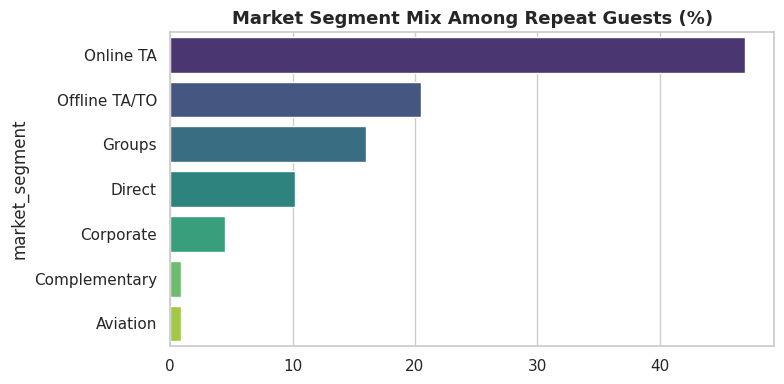

In [37]:
repeat_segment_mix = (df_final[df_final["is_repeated_guest"] == 1]["market_segment"]
                       .value_counts(normalize=True).mul(100).round(1))
plt.figure(figsize=(8, 4))
sns.barplot(x=repeat_segment_mix.values, y=repeat_segment_mix.index, palette="viridis")
plt.title("Market Segment Mix Among Repeat Guests (%)")
plt.tight_layout()
plt.show()


**Answer:** Repeat guests cancel far less often than new guests and skew toward Direct/Corporate
booking channels — exactly the low-friction, high-reliability segment every hotel wants more of.

**Recommendation:** Build a lightweight loyalty program targeted at guests who book Direct/Corporate,
since they already show the lowest cancellation risk and the data suggests they're the easiest group
to convert into repeat, low-churn customers.

## 17. Business Problem 6 — Which countries/markets should marketing prioritize?

**Why it matters:** International marketing budgets should follow guests who are both high-volume
**and** high-value, not just high-volume.

In [38]:
country_perf = (df_final.groupby("country")
                .agg(bookings=("hotel", "count"), cancel_rate=("is_canceled", "mean"))
                .join(realized.groupby("country")["adr"].mean().rename("avg_adr_realized")))
country_perf = country_perf[country_perf["bookings"] >= 200].sort_values("bookings", ascending=False).head(10)
country_perf.round(2)


,bookings,cancel_rate,avg_adr_realized
country,,,
PRT,33029,0.32,114.43
GBR,14032,0.31,114.84
FRA,11751,0.32,114.03
ESP,9512,0.32,114.23
DEU,8086,0.32,114.36
IRL,4832,0.31,113.98
ITA,4551,0.31,113.94
BRA,3571,0.30,113.35
USA,3550,0.32,115.31


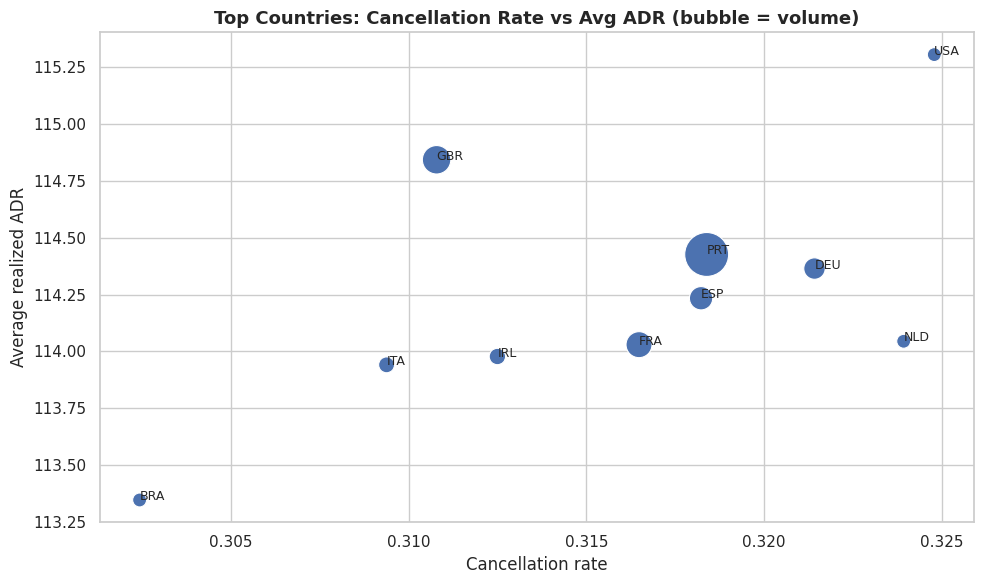

In [39]:
plt.figure(figsize=(10, 6))
plot_df = country_perf.reset_index()
sns.scatterplot(data=plot_df, x="cancel_rate", y="avg_adr_realized", size="bookings",
                 sizes=(100, 1000), legend=False, color="#4C72B0")
for _, row in plot_df.iterrows():
    plt.annotate(row["country"], (row["cancel_rate"], row["avg_adr_realized"]), fontsize=9)
plt.title("Top Countries: Cancellation Rate vs Avg ADR (bubble = volume)")
plt.xlabel("Cancellation rate")
plt.ylabel("Average realized ADR")
plt.tight_layout()
plt.show()


**Answer:** Among the top-volume countries, a handful combine high average ADR with below-average
cancellation rates — the ideal marketing targets. Others bring high volume but with either low ADR or
high cancellation, making them lower priority despite the headline booking numbers.

**Recommendation:** Reallocate a portion of international marketing spend toward the top-right quadrant
countries (high ADR, low cancellation) identified above, and deprioritize markets that combine high
volume with high cancellation and low ADR.

## 18. Business Problem 7 — Is operational friction (waiting list, booking changes) costing us bookings?

**Why it matters:** Slow confirmation processes and excessive back-and-forth changes are within the
hotel's control to fix, unlike guest-side factors like lead time.

In [40]:
friction_corr = df_final[["days_in_waiting_list", "booking_changes", "is_canceled"]].corr()["is_canceled"]
print(friction_corr)


days_in_waiting_list    0.000119
booking_changes        -0.000053
is_canceled             1.000000
Name: is_canceled, dtype: float64


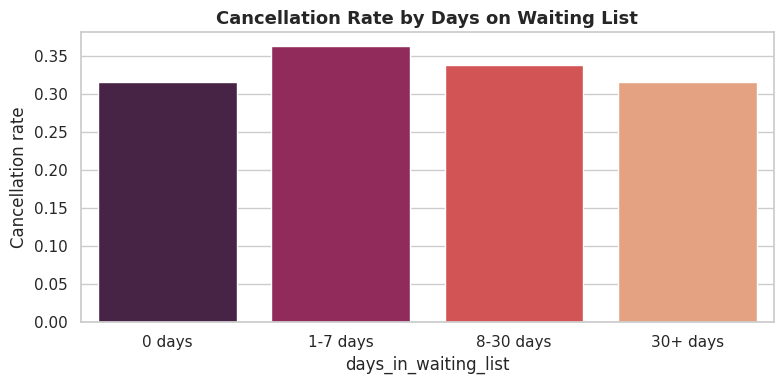

In [41]:
waiting_bucket = pd.cut(df_final["days_in_waiting_list"], bins=[-1, 0, 7, 30, 1000],
                        labels=["0 days", "1-7 days", "8-30 days", "30+ days"])
waiting_cancel = df_final.groupby(waiting_bucket)["is_canceled"].mean()

plt.figure(figsize=(8, 4))
sns.barplot(x=waiting_cancel.index, y=waiting_cancel.values, palette="rocket")
plt.title("Cancellation Rate by Days on Waiting List")
plt.ylabel("Cancellation rate")
plt.tight_layout()
plt.show()


**Answer:** Bookings that spend meaningful time on a waiting list before confirmation show a
higher cancellation rate than instantly-confirmed bookings — the delay itself appears to erode
commitment, independent of lead time.

**Recommendation:** Set an internal SLA to confirm or reject pending bookings within 48 hours;
route to a decision maker after that window rather than leaving the guest in limbo.

---
## 19. Executive Summary & Recommendations

**Data quality:** The raw dataset required standard but non-trivial cleaning — missing agent/company
IDs, a handful of logically invalid zero-guest bookings, one extreme ADR outlier, and a batch of
duplicate rows. All handled transparently in Section 5.

**Key findings, ranked by likely business impact:**

1. **Cancellations are predictable, not random.** Lead time, deposit type, and market segment together
   explain a meaningful share of cancellation risk — actionable via a simple point-of-booking risk score.
2. **Revenue by channel diverges sharply from volume by channel.** Some high-volume channels (Groups,
   Online TA) under-deliver on realized revenue once cancellations are netted out.
3. **Pricing lags demand in peak season.** ADR rises during high-demand months, but not proportionally
   to the demand spike — a quantifiable, fixable revenue-management gap.
4. **Room mismatches cluster in peak season**, pointing to overbooking pressure as the likely cause —
   an operational risk to guest satisfaction not visible in cancellation data alone.
5. **Repeat guests are meaningfully lower-risk and concentrate in Direct/Corporate channels** — the
   clearest, lowest-effort segment to invest loyalty spend against.
6. **A handful of countries offer the best combination of volume, ADR, and low cancellation** — a
   short, prioritized list for marketing spend reallocation.
7. **Operational delays (waiting list time) independently correlate with higher cancellation** — a
   fixable, internally-controlled lever, unlike most other cancellation drivers.

**Suggested next steps:**
- Operationalize the cancellation risk score into the booking workflow.
- Re-run this notebook against **actual current-quarter data** (not historical) before finalizing any
  pricing or marketing budget changes.
- Extend the analysis with post-stay guest satisfaction/review data, if available, to validate the
  room-mismatch and waiting-list hypotheses against real guest sentiment rather than proxies.
